In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile
import os

zip_file = "archive.zip"
extract_path = "/content/amazon_reviews"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")
print(os.listdir(extract_path))

Files extracted successfully!
['amazon_ebook_Data.csv', 'amazon_grocery_Data.csv', 'amazon_books_Data.csv', 'amazon_pc_Data.csv', 'amazon_jwellery_Data.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [5]:
import glob
import os

files_list = glob.glob("/content/amazon_reviews/**/*.csv", recursive=True)

print("CSV files found:")
for file in files_list:
    print(os.path.basename(file))

CSV files found:
amazon_ebook_Data.csv
amazon_grocery_Data.csv
amazon_books_Data.csv
amazon_pc_Data.csv
amazon_jwellery_Data.csv


In [6]:
dataframes = []

for file in files_list:
    df_temp = pd.read_csv(file)

    # Add category from filename
    filename = os.path.basename(file).lower()

    if "books" in filename:
        category = "Books"
    elif "ebook" in filename:
        category = "Ebooks"
    elif "grocery" in filename:
        category = "Grocery"
    elif "jwellery" in filename or "jewellery" in filename:
        category = "Jewellery"
    elif "pc" in filename:
        category = "PC"
    else:
        category = "Other"

    df_temp["product_category"] = category
    dataframes.append(df_temp)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [11]:
print("Dataset Shape:", amazon_df.shape)

print("\nNumerical Summary:")
display(amazon_df.describe())

Dataset Shape: (500, 24)

Numerical Summary:


,Unnamed: 0,star_rating,helpful_votes,total_votes,review_year
count,500.000000,500.000000,500.000000,500.000000,100.0
mean,49.500000,0.796000,0.764000,1.068000,2015.0
std,28.894979,0.403373,2.843321,3.698477,0.0
min,0.000000,0.000000,0.000000,0.000000,2015.0
25%,24.750000,1.000000,0.000000,0.000000,2015.0
50%,49.500000,1.000000,0.000000,0.000000,2015.0
75%,74.250000,1.000000,1.000000,1.000000,2015.0
max,99.000000,1.000000,36.000000,47.000000,2015.0


In [12]:
print("Unique values in important columns:\n")

print("Product Categories:", amazon_df['product_category'].nunique())
print("Products:", amazon_df['product_id'].nunique())
print("Customers:", amazon_df['customer_id'].nunique())
print("Reviews:", amazon_df['review_id'].nunique())
print("Star Ratings:", sorted(amazon_df['star_rating'].unique()))

Unique values in important columns:

Product Categories: 5
Products: 496
Customers: 491
Reviews: 500
Star Ratings: [np.int64(0), np.int64(1)]


In [7]:
for i, df_temp in enumerate(dataframes):
    print(f"\nDataset {i+1}")
    print("Shape:", df_temp.shape)
    print("Columns:")
    print(df_temp.columns.tolist())


Dataset 1
Shape: (100, 17)
Columns:
['Unnamed: 0', 'market_place', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'Sentiment_ebook']

Dataset 2
Shape: (100, 17)
Columns:
['Unnamed: 0', 'market_place', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'Sentiment_grcry']

Dataset 3
Shape: (100, 20)
Columns:
['Unnamed: 0', 'market_place', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'Sentiment_books', 'review_month', 'review_day', 'review_year']

Dataset 4
Shape: (100, 17)


In [28]:
# Check review text before cleaning

print("Total reviews:", len(amazon_df))
print("Missing review_body:", amazon_df["review_body"].isna().sum())

amazon_df[["review_body", "star_rating"]].head(10)

Total reviews: 500
Missing review_body: 0


,review_body,star_rating
0,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",1
1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",1
2,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",1
3,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",1
4,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",1
5,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",0
6,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",1
7,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",1
8,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",1
9,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",1


In [8]:
amazon_df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", amazon_df.shape)
amazon_df.head()

Combined dataset shape: (500, 24)


,Unnamed: 0,market_place,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,Sentiment_ebook,Sentiment_grcry,Sentiment_books,review_month,review_day,review_year,Sentiment_pc,Sentiment_jwlry
0,0,"""US""","""33605939""","""RGYFDX8QXKEIR""","""B007KO2MLO""","""328837464""","""Big Maria""",Ebooks,1,0,0,0 \t(N),0 \t(N),"""Quirky""","""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",2013-09-09,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"""US""","""34058393""","""R13CBGTMNV9R8Z""","""B005FLODDE""","""764276359""","""The Woman Who Wasn't There: The True Story of an Incredible Deception""",Ebooks,1,1,2,0 \t(N),1 \t(Y),"""The Woman Who Wasn't There""","""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",2013-09-09,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"""US""","""39601147""","""R7DRFHC0F71O0""","""B00EA3L35O""","""535606445""","""Mary had A Sleepy Sheep""",Ebooks,1,0,0,0 \t(N),0 \t(N),"""This Sleepy Sheep rocks!""","""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",2013-09-09,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"""US""","""17351407""","""R27LUKEXU3KBXQ""","""B00BL3JV50""","""240053004""","""Starstruck""",Ebooks,1,1,1,0 \t(N),1 \t(Y),"""Steamy and suspenseful!!!!!""","""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",2013-09-09,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"""US""","""10463387""","""R1VXTPUYMNU687""","""B00CXU7U80""","""931529805""","""The Complete Conan Saga""",Ebooks,1,1,2,0 \t(N),0 \t(N),"""Barbarians""","""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",2013-09-09,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("Number of rows:", amazon_df.shape[0])
print("Number of columns:", amazon_df.shape[1])

amazon_df.info()

Number of rows: 500
Number of columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         500 non-null    int64  
 1   market_place       500 non-null    object 
 2   customer_id        500 non-null    object 
 3   review_id          500 non-null    object 
 4   product_id         500 non-null    object 
 5   product_parent     500 non-null    object 
 6   product_title      500 non-null    object 
 7   product_category   500 non-null    object 
 8   star_rating        500 non-null    int64  
 9   helpful_votes      500 non-null    int64  
 10  total_votes        500 non-null    int64  
 11  vine               500 non-null    object 
 12  verified_purchase  500 non-null    object 
 13  review_headline    500 non-null    object 
 14  review_body        500 non-null    object 
 15  review_date        500 non-null 

In [29]:
import re
import string

def clean_text(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r"<.*?>", " ", text)         # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text) # remove URLs
    text = re.sub(r"\d+", " ", text)           # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # punctuation
    text = re.sub(r"\s+", " ", text).strip()   # extra spaces
    return text

amazon_df["clean_review"] = amazon_df["review_body"].apply(clean_text)

amazon_df[["review_body", "clean_review"]].head(10)

,review_body,clean_review
0,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",elmore leonard meets the cast of sierra madre just a quirky read that will make you want to keep trying no matter what happens
1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",this book was very interesting it is a true story about a woman who perpetrated a lie about her survival of the attack on it was so amazing to me that she couldwould do such a thing it had such a ...
2,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",i had the opportunity to review mary had a sleepy sheep by julia dweck with my kindergarten class and they thought it was hysterical we have read this story multiple times and its just as funny ev...
3,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",what a great read i really couldnt put this book down a suspenseful twist in this steamy love story will keep you reading where can i find a jesse just loved his relationship with sam youve gotta ...
4,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",barbarians need love too short stories work well with ebooks the texts can be printed and read later they can be read on a laptop bravo
5,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",it was okay obviously but if you hadnt read the other beginning books well it would be confusing plus theres the fact that it did not tell me that it was a script for a play though the plot is sor...
6,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",very interesting and kept me reading read it in one day didnt get much of anything else done very good
7,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",really enjoyed this book and the author ready to read the next one thanks for keeping me intrigued and unable to put my book down
8,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",i really liked this book i felt like i got to know the characters it was a really good read
9,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",reading callum and stellas story was a bit like watching a tennis match they bounced like a tennis ball back and forth from his side of the court to her side of the court they were together then n...


In [31]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

amazon_df["clean_review"] = amazon_df["clean_review"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

amazon_df[["review_body", "clean_review"]].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review_body,clean_review
0,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",elmore leonard meets cast sierra madre quirky read make want keep trying matter happens
1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",book interesting true story woman perpetrated lie survival attack amazing couldwould thing devastating effect many
2,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",opportunity review mary sleepy sheep julia dweck kindergarten class thought hysterical read story multiple times funny every time little girl sheep sleepy matter tries wake tries pretty crazy thin...
3,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",great read really couldnt put book suspenseful twist steamy love story keep reading find jesse loved relationship sam youve gotta read story wont disappoint
4,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",barbarians need love short stories work well ebooks texts printed read later read laptop bravo
5,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",okay obviously hadnt read beginning books well would confusing plus theres fact tell script play though plot sort good get kind idea happened
6,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",interesting kept reading read one day didnt get much anything else done good
7,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",really enjoyed book author ready read next one thanks keeping intrigued unable put book
8,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",really liked book felt like got know characters really good read
9,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",reading callum stellas story bit like watching tennis match bounced like tennis ball back forth side court side court together together together like tennis match entertaining times nerve racking ...


In [32]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

amazon_df["sentiment"] = amazon_df["star_rating"].apply(get_sentiment)

print(amazon_df["sentiment"].value_counts())

sentiment
Negative    500
Name: count, dtype: int64


In [33]:
print("Dataset shape:", amazon_df.shape)

print("\nSentiment distribution:")
print(amazon_df["sentiment"].value_counts())

print("\nSample processed data:")
display(
    amazon_df[
        ["product_category", "star_rating", "review_body",
         "clean_review", "sentiment"]
    ].head(10)
)

Dataset shape: (500, 27)

Sentiment distribution:
sentiment
Negative    500
Name: count, dtype: int64

Sample processed data:


,product_category,star_rating,review_body,clean_review,sentiment
0,Ebooks,1,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",elmore leonard meets cast sierra madre quirky read make want keep trying matter happens,Negative
1,Ebooks,1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",book interesting true story woman perpetrated lie survival attack amazing couldwould thing devastating effect many,Negative
2,Ebooks,1,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",opportunity review mary sleepy sheep julia dweck kindergarten class thought hysterical read story multiple times funny every time little girl sheep sleepy matter tries wake tries pretty crazy thin...,Negative
3,Ebooks,1,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",great read really couldnt put book suspenseful twist steamy love story keep reading find jesse loved relationship sam youve gotta read story wont disappoint,Negative
4,Ebooks,1,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",barbarians need love short stories work well ebooks texts printed read later read laptop bravo,Negative
5,Ebooks,0,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",okay obviously hadnt read beginning books well would confusing plus theres fact tell script play though plot sort good get kind idea happened,Negative
6,Ebooks,1,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",interesting kept reading read one day didnt get much anything else done good,Negative
7,Ebooks,1,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",really enjoyed book author ready read next one thanks keeping intrigued unable put book,Negative
8,Ebooks,1,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",really liked book felt like got know characters really good read,Negative
9,Ebooks,1,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",reading callum stellas story bit like watching tennis match bounced like tennis ball back forth side court side court together together together like tennis match entertaining times nerve racking ...,Negative


In [34]:
print("Dataset shape:", amazon_df.shape)

print("\nSentiment distribution:")
print(amazon_df["sentiment"].value_counts())

print("\nSample processed data:")
display(
    amazon_df[
        ["product_category", "star_rating", "review_body",
         "clean_review", "sentiment"]
    ].head(10)
)

Dataset shape: (500, 27)

Sentiment distribution:
sentiment
Negative    500
Name: count, dtype: int64

Sample processed data:


,product_category,star_rating,review_body,clean_review,sentiment
0,Ebooks,1,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",elmore leonard meets cast sierra madre quirky read make want keep trying matter happens,Negative
1,Ebooks,1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",book interesting true story woman perpetrated lie survival attack amazing couldwould thing devastating effect many,Negative
2,Ebooks,1,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",opportunity review mary sleepy sheep julia dweck kindergarten class thought hysterical read story multiple times funny every time little girl sheep sleepy matter tries wake tries pretty crazy thin...,Negative
3,Ebooks,1,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",great read really couldnt put book suspenseful twist steamy love story keep reading find jesse loved relationship sam youve gotta read story wont disappoint,Negative
4,Ebooks,1,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",barbarians need love short stories work well ebooks texts printed read later read laptop bravo,Negative
5,Ebooks,0,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",okay obviously hadnt read beginning books well would confusing plus theres fact tell script play though plot sort good get kind idea happened,Negative
6,Ebooks,1,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",interesting kept reading read one day didnt get much anything else done good,Negative
7,Ebooks,1,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",really enjoyed book author ready read next one thanks keeping intrigued unable put book,Negative
8,Ebooks,1,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",really liked book felt like got know characters really good read,Negative
9,Ebooks,1,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",reading callum stellas story bit like watching tennis match bounced like tennis ball back forth side court side court together together together like tennis match entertaining times nerve racking ...,Negative


In [35]:
from sklearn.model_selection import train_test_split

X = amazon_df["clean_review"]
y = amazon_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 400
Testing reviews: 100


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (400, 1278)
Testing feature shape: (100, 1278)


In [38]:
# Convert star_rating to numeric
amazon_df["star_rating"] = pd.to_numeric(
    amazon_df["star_rating"],
    errors="coerce"
)

# Remove rows where rating is invalid
amazon_df = amazon_df.dropna(subset=["star_rating"]).copy()

# Create sentiment correctly
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

amazon_df["sentiment"] = amazon_df["star_rating"].apply(get_sentiment)

print("Sentiment distribution:")
print(amazon_df["sentiment"].value_counts())

Sentiment distribution:
sentiment
Negative    500
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

X = amazon_df["clean_review"]
y = amazon_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training sentiment:")
print(y_train.value_counts())

print("\nTesting sentiment:")
print(y_test.value_counts())

Training sentiment:
sentiment
Negative    400
Name: count, dtype: int64

Testing sentiment:
sentiment
Negative    100
Name: count, dtype: int64


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training features:", X_train_tfidf.shape)
print("Testing features:", X_test_tfidf.shape)

Training features: (400, 1278)
Testing features: (100, 1278)


In [43]:
print("STAR RATINGS:")
print(amazon_df["star_rating"].value_counts(dropna=False).sort_index())

print("\nSENTIMENT:")
print(amazon_df["sentiment"].value_counts(dropna=False))

print("\nSENTIMENT DATA TYPES:")
print(amazon_df["sentiment"].dtype)

STAR RATINGS:
star_rating
0    102
1    398
Name: count, dtype: int64

SENTIMENT:
sentiment
Negative    500
Name: count, dtype: int64

SENTIMENT DATA TYPES:
object


In [44]:
print(amazon_df[["star_rating", "sentiment"]].head(20))

    star_rating sentiment
0             1  Negative
1             1  Negative
2             1  Negative
3             1  Negative
4             1  Negative
5             0  Negative
6             1  Negative
7             1  Negative
8             1  Negative
9             1  Negative
10            1  Negative
11            1  Negative
12            1  Negative
13            1  Negative
14            1  Negative
15            0  Negative
16            1  Negative
17            1  Negative
18            0  Negative
19            1  Negative


In [45]:
print("Unique star_rating values:")
print(sorted(amazon_df["star_rating"].unique()))

print("\nRating counts:")
print(amazon_df["star_rating"].value_counts().sort_index())

Unique star_rating values:
[np.int64(0), np.int64(1)]

Rating counts:
star_rating
0    102
1    398
Name: count, dtype: int64


In [46]:
for file in files_list:
    temp = pd.read_csv(file)

    print("\n", os.path.basename(file))
    print(temp["star_rating"].value_counts().sort_index())


 amazon_ebook_Data.csv
star_rating
0    18
1    82
Name: count, dtype: int64

 amazon_grocery_Data.csv
star_rating
0    17
1    83
Name: count, dtype: int64

 amazon_books_Data.csv
star_rating
0    16
1    84
Name: count, dtype: int64

 amazon_pc_Data.csv
star_rating
0    26
1    74
Name: count, dtype: int64

 amazon_jwellery_Data.csv
star_rating
0    25
1    75
Name: count, dtype: int64


In [47]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [48]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

amazon_df["sentiment"] = amazon_df["review_body"].apply(classify_sentiment)

print(amazon_df["sentiment"].value_counts())

sentiment
Positive    376
Neutral      66
Negative     58
Name: count, dtype: int64


In [49]:
display(
    amazon_df[
        ["review_body", "star_rating", "sentiment"]
    ].head(20)
)

,review_body,star_rating,sentiment
0,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",1,Negative
1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",1,Positive
2,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",1,Positive
3,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",1,Positive
4,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",1,Positive
5,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",0,Positive
6,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",1,Positive
7,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",1,Positive
8,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",1,Positive
9,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",1,Positive


In [50]:
from sklearn.model_selection import train_test_split

X = amazon_df["clean_review"]
y = amazon_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training classes:")
print(y_train.value_counts())

Training classes:
sentiment
Positive    301
Neutral      53
Negative     46
Name: count, dtype: int64


In [51]:
display(
    amazon_df[
        ["review_body", "star_rating", "sentiment"]
    ].head(20)
)

,review_body,star_rating,sentiment
0,"""Elmore Leonard meets the cast of Sierra Madre. Just a quirky read that will make you want to keep trying no matter what happens.""",1,Negative
1,"""This book was very interesting. It is a true story about a woman who perpetrated a lie about her survival of the attack on 9/11. It was so amazing to me that she could/would do such a thing. It h...",1,Positive
2,"""I had the opportunity to review Mary had a Sleepy Sheep by Julia Dweck with my kindergarten class and they thought it was hysterical! We have read this story multiple times and it's just as funny...",1,Positive
3,"""What a great read! I really couldn't put this book down! A suspenseful twist in this steamy love story will keep you reading!! Where can I find a Jesse?!?! Just loved his relationship with Sam. Y...",1,Positive
4,"""Barbarians need love too ! Short stories work well with ebooks. The texts can be printed and read later. They can be read on a laptop. Bravo !""",1,Positive
5,"""It was okay obviously, but if you hadn't read the other beginning ' books,' well it would be confusing. Plus, there's the fact that it did not tell me that it was a script for a play, though the ...",0,Positive
6,"""Very interesting and kept me reading. Read it in one day. Didn't get much of anything else done. Very good ..""",1,Positive
7,"""Really enjoyed this book and the author! Ready to read the next one! Thanks for keeping me intrigued and unable to put my book down.""",1,Positive
8,"""I really liked this book. I felt like I got to know the characters. It was a really good read.""",1,Positive
9,"""Reading Callum and Stella's story was a bit like watching a tennis match. They bounced like a tennis ball back and forth from his side of the court to her side of the court. They were together th...",1,Positive


In [52]:
from sklearn.model_selection import train_test_split

X = amazon_df["clean_review"]
y = amazon_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training classes:")
print(y_train.value_counts())

Training classes:
sentiment
Positive    301
Neutral      53
Negative     46
Name: count, dtype: int64


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)

Training shape: (400, 1206)


In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [55]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 75.0 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        12
     Neutral       0.00      0.00      0.00        13
    Positive       0.75      1.00      0.86        75

    accuracy                           0.75       100
   macro avg       0.25      0.33      0.29       100
weighted avg       0.56      0.75      0.64       100



In [56]:
print(amazon_df["sentiment"].value_counts())

sentiment
Positive    376
Neutral      66
Negative     58
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    amazon_df["clean_review"],
    amazon_df["sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=amazon_df["sentiment"]
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(400, 10000)


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = amazon_df["clean_review"]
y = amazon_df["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

# Prediction
y_pred = model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"],
    zero_division=0
))

Accuracy: 75.0 %

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.17      0.29        12
     Neutral       0.36      0.38      0.37        13
    Positive       0.81      0.91      0.86        75

    accuracy                           0.75       100
   macro avg       0.72      0.49      0.50       100
weighted avg       0.77      0.75      0.72       100



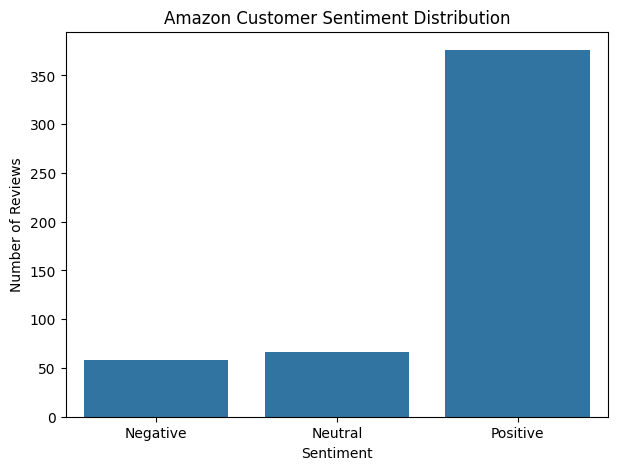

In [60]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=amazon_df,
    x="sentiment",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Amazon Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [61]:
# Customer satisfaction and product improvement insights

# 1. Sentiment distribution by product category
category_sentiment = pd.crosstab(
    amazon_df["product_category"],
    amazon_df["sentiment"],
    normalize="index"
) * 100

category_sentiment = category_sentiment.round(2)

print("Sentiment Percentage by Product Category:")
display(category_sentiment)

Sentiment Percentage by Product Category:


sentiment,Negative,Neutral,Positive
product_category,,,
Books,8.0,11.0,81.0
Ebooks,11.0,7.0,82.0
Grocery,8.0,16.0,76.0
Jewellery,13.0,13.0,74.0
PC,18.0,19.0,63.0


In [62]:
# Make sure all sentiment columns exist
for col in ["Positive", "Neutral", "Negative"]:
    if col not in category_sentiment.columns:
        category_sentiment[col] = 0

# Arrange columns
category_sentiment = category_sentiment[
    ["Positive", "Neutral", "Negative"]
]

print("Customer Sentiment by Product Category (%)")
display(category_sentiment)

Customer Sentiment by Product Category (%)


sentiment,Positive,Neutral,Negative
product_category,,,
Books,81.0,11.0,8.0
Ebooks,82.0,7.0,11.0
Grocery,76.0,16.0,8.0
Jewellery,74.0,13.0,13.0
PC,63.0,19.0,18.0


In [63]:
print("========== PRODUCT IMPROVEMENT & CUSTOMER SATISFACTION INSIGHTS ==========\n")

# Overall sentiment
overall = amazon_df["sentiment"].value_counts(normalize=True) * 100

print(f"1. Overall Customer Satisfaction:")
print(f"   Positive reviews: {overall.get('Positive', 0):.2f}%")
print(f"   Neutral reviews: {overall.get('Neutral', 0):.2f}%")
print(f"   Negative reviews: {overall.get('Negative', 0):.2f}%")

print("\n2. Category-wise Insights:")

for category in category_sentiment.index:
    positive = category_sentiment.loc[category, "Positive"]
    neutral = category_sentiment.loc[category, "Neutral"]
    negative = category_sentiment.loc[category, "Negative"]

    print(f"\n   {category}:")
    print(f"   - Positive: {positive:.2f}%")
    print(f"   - Neutral: {neutral:.2f}%")
    print(f"   - Negative: {negative:.2f}%")

    if negative > 20:
        print("   → Higher negative feedback indicates an area requiring product/service improvement.")
    elif negative > 10:
        print("   → Some negative feedback exists and should be reviewed for recurring complaints.")
    else:
        print("   → Negative feedback is relatively limited.")

    if neutral > 15:
        print("   → Neutral feedback suggests opportunities to improve customer experience.")

========== PRODUCT IMPROVEMENT & CUSTOMER SATISFACTION INSIGHTS ==========

1. Overall Customer Satisfaction:
   Positive reviews: 75.20%
   Neutral reviews: 13.20%
   Negative reviews: 11.60%

2. Category-wise Insights:

   Books:
   - Positive: 81.00%
   - Neutral: 11.00%
   - Negative: 8.00%
   → Negative feedback is relatively limited.

   Ebooks:
   - Positive: 82.00%
   - Neutral: 7.00%
   - Negative: 11.00%
   → Some negative feedback exists and should be reviewed for recurring complaints.

   Grocery:
   - Positive: 76.00%
   - Neutral: 16.00%
   - Negative: 8.00%
   → Negative feedback is relatively limited.
   → Neutral feedback suggests opportunities to improve customer experience.

   Jewellery:
   - Positive: 74.00%
   - Neutral: 13.00%
   - Negative: 13.00%
   → Some negative feedback exists and should be reviewed for recurring complaints.

   PC:
   - Positive: 63.00%
   - Neutral: 19.00%
   - Negative: 18.00%
   → Some negative feedback exists and should be reviewed for

In [64]:
# Categories with higher negative sentiment

attention_categories = category_sentiment.sort_values(
    by="Negative",
    ascending=False
)

print("Categories ordered by negative feedback:")
display(attention_categories)

Categories ordered by negative feedback:


sentiment,Positive,Neutral,Negative
product_category,,,
PC,63.0,19.0,18.0
Jewellery,74.0,13.0,13.0
Ebooks,82.0,7.0,11.0
Books,81.0,11.0,8.0
Grocery,76.0,16.0,8.0


<Figure size 1000x600 with 0 Axes>

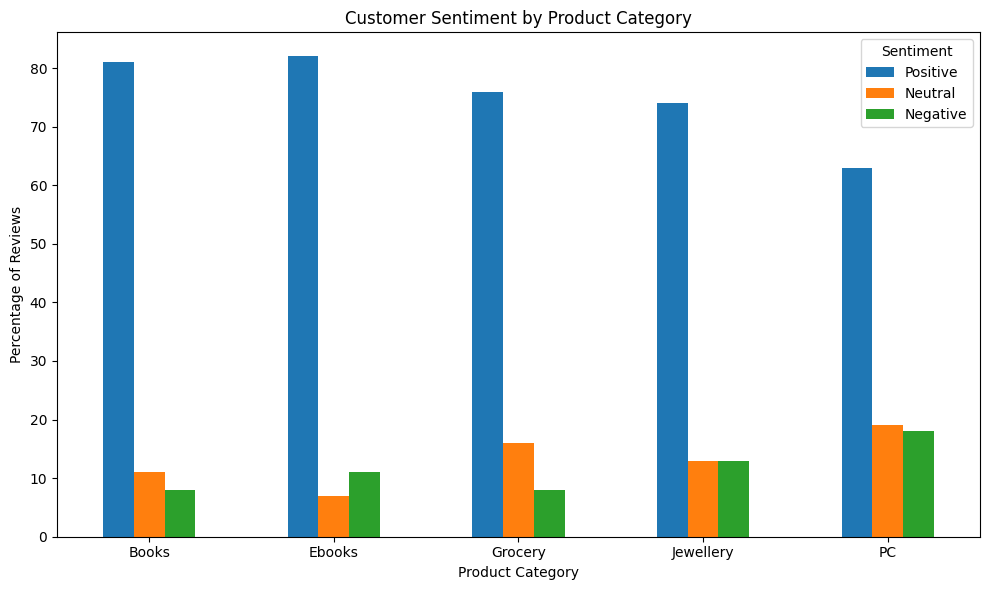

In [65]:
plt.figure(figsize=(10, 6))

category_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Sentiment by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()